In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the Titanic dataset (built-in, no download needed)
df = sns.load_dataset('titanic')

print("✅ Dataset loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()  # Shows first 5 rows

✅ Dataset loaded!
Rows: 891, Columns: 15


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Check basic info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values (count per column) ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

=== Missing Values (count per column) ===
survived       

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# 1. Fill missing 'age' with the median age
df['age'].fillna(df['age'].median(), inplace=True)

# 2. Fill missing 'embarked' with most common value
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# 3. Drop 'deck' column — it has too many missing values
df.drop(columns=['deck'], inplace=True)

# 4. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 5. Remove outliers in 'fare' using IQR method
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['fare'] < (Q1 - 1.5*IQR)) | (df['fare'] > (Q3 + 1.5*IQR)))]

print("✅ Data cleaned!")
print(f"Remaining missing values:\n{df.isnull().sum()}")
print(f"\nFinal dataset shape: {df.shape}")

✅ Data cleaned!
Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Final dataset shape: (673, 14)


/tmp/ipykernel_5227/2407652311.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_5227/2407652311.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

/tmp/ipykernel_5227/1296353575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=df, palette='Set2')


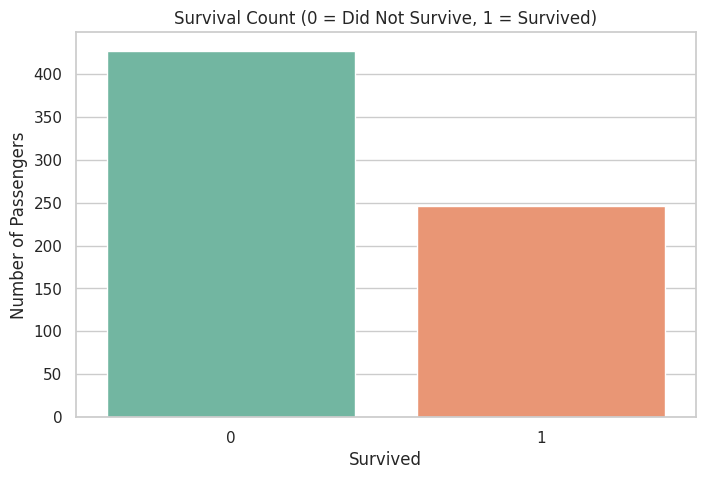

✅ Chart 1 saved!


In [5]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.countplot(x='survived', data=df, palette='Set2')
plt.title('Survival Count (0 = Did Not Survive, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.savefig('chart1_survival_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

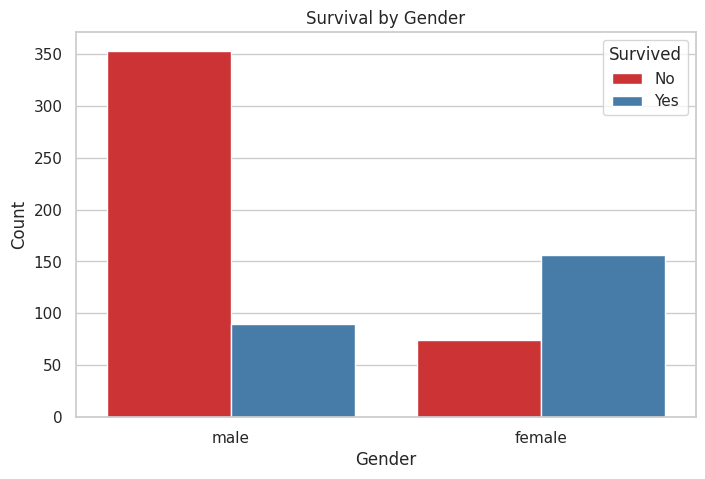

✅ Chart 2 saved!


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', hue='survived', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.savefig('chart2_survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

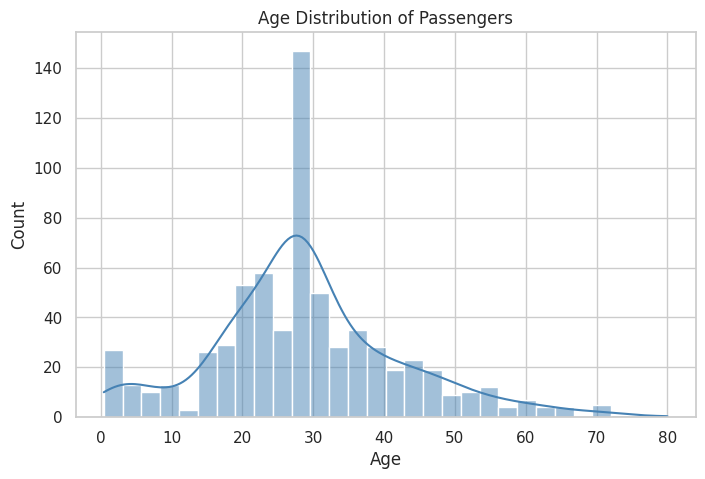

✅ Chart 3 saved!


In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('chart3_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

/tmp/ipykernel_5227/258281414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='fare', data=df, palette='pastel')


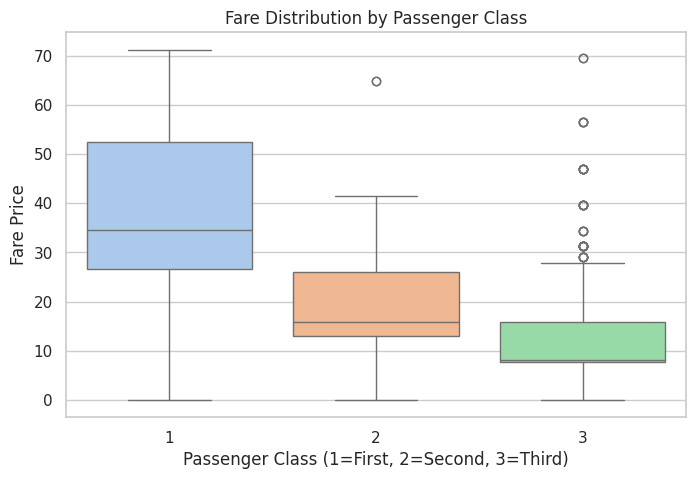

✅ Chart 4 saved!


In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='pclass', y='fare', data=df, palette='pastel')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')
plt.ylabel('Fare Price')
plt.savefig('chart4_fare_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

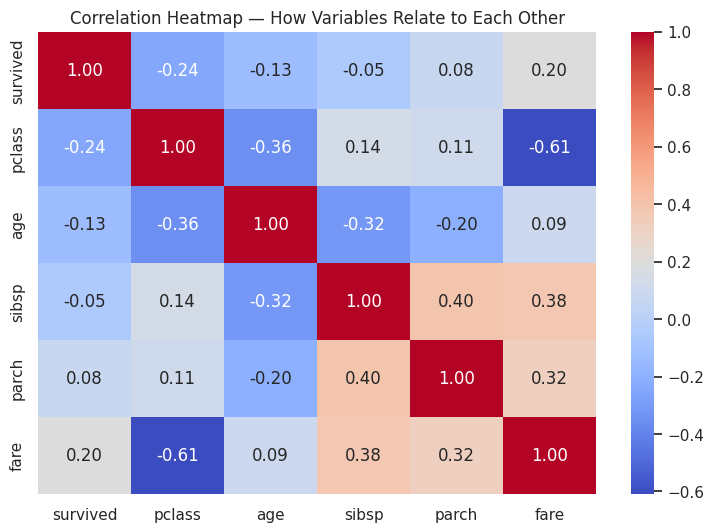

✅ Chart 5 saved!


In [9]:
plt.figure(figsize=(9, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — How Variables Relate to Each Other')
plt.savefig('chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

In [10]:
# Save cleaned dataset
df.to_csv('titanic_cleaned.csv', index=False)

print("✅ Cleaned dataset saved!")
print("\n🎉 Task 1 COMPLETE!")
print("\nFiles created:")
print("  • titanic_cleaned.csv")
print("  • chart1_survival_count.png")
print("  • chart2_survival_by_gender.png")
print("  • chart3_age_distribution.png")
print("  • chart4_fare_by_class.png")
print("  • chart5_correlation_heatmap.png")

✅ Cleaned dataset saved!

🎉 Task 1 COMPLETE!

Files created:
  • titanic_cleaned.csv
  • chart1_survival_count.png
  • chart2_survival_by_gender.png
  • chart3_age_distribution.png
  • chart4_fare_by_class.png
  • chart5_correlation_heatmap.png
